# 18. Dataset Diagnostic Landscape Report

**Project**: Master Thesis — Contract Renegotiation Prediction
**Objective**: Establish a diagnostic baseline for the dataset to validate its suitability for weak supervision and few-shot meta-learning pipelines.

This report provides a structured overview of the contract data landscape, focusing on department distribution, gold-label coverage, and Stage 2 task validity.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Setup Paths
PROJECT_ROOT = Path("..")
DATA_PATH = PROJECT_ROOT / "Data" / "processed" / "contract_with_features_labeled.csv"
REPORT_DIR = PROJECT_ROOT / "reports" / "diagnostics"
FIGURE_DIR = REPORT_DIR / "figures"

REPORT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------------------------------
# Helper Functions
# -----------------------------------------------------------------------------

def save_table(df, name):
    path = REPORT_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    print(f"Saved table to: {path}")

def save_figure(name):
    path = FIGURE_DIR / f"{name}.png"
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved figure to: {path}")
    plt.show()

# 1. Load Data
if not DATA_PATH.exists():
    DATA_PATH = PROJECT_ROOT / "Data" / "processed" / "contracts_with_features.csv"

df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Loaded dataset from: {DATA_PATH}")

Loaded dataset from: ../Data/processed/contract_with_features_labeled.csv


## 1. Dataset Overview

This section summarizes the high-level statistics of the dataset, including unique identifiers and data types.

In [2]:
overview = {
    "metric": [
        "Number of rows",
        "Unique contract_id",
        "Unique supplier_id",
        "Number of departments",
        "Observation years covered",
        "Numeric columns",
        "Categorical columns",
        "Boolean columns",
        "Columns with missing values",
        "Duplicate contract_ids"
    ],
    "value": [
        len(df),
        df['contract_id'].nunique(),
        df['supplier_id'].nunique(),
        df['department'].nunique(),
        f"{df['observation_year'].min()} - {df['observation_year'].max()}",
        len(df.select_dtypes(include=[np.number]).columns),
        len(df.select_dtypes(include=['object', 'string']).columns),
        len(df.select_dtypes(include=['bool']).columns),
        df.isnull().any().sum(),
        df['contract_id'].duplicated().sum()
    ]
}
df_overview = pd.DataFrame(overview)
display(df_overview)
save_table(df_overview, "dataset_overview")

,metric,value
0,Number of rows,9201
1,Unique contract_id,2209
2,Unique supplier_id,583
3,Number of departments,14
4,Observation years covered,2015 - 2025
5,Numeric columns,121
6,Categorical columns,41
7,Boolean columns,0
8,Columns with missing values,91
9,Duplicate contract_ids,6992


Saved table to: ../reports/diagnostics/dataset_overview.csv


## 2. Contract Distribution by Department

Understanding the distribution of contracts across departments is essential for assessing the diversity of source tasks for meta-learning.

,department,n_rows,n_unique_contracts,pct_contracts
3,Devices & Needles,2197,476,21.76
4,Drug Product Outsourcing,589,300,13.72
5,Drug Substance Outsourcing,943,298,13.63
9,Packaging Material,1272,289,13.21
11,Raw Materials & Energy,1555,281,12.85
10,"Quality, Production Services & Supplies",1044,215,9.83
1,Bioprocessing & Raw Materials,679,113,5.17
8,Logistics,282,94,4.30
2,Bioprocessing and Excipients,218,59,2.70
0,"Alliance, Acquisitions & PPM CoE",270,35,1.60


Saved table to: ../reports/diagnostics/department_contract_distribution.csv
Saved figure to: ../reports/diagnostics/figures/department_contract_bar.png


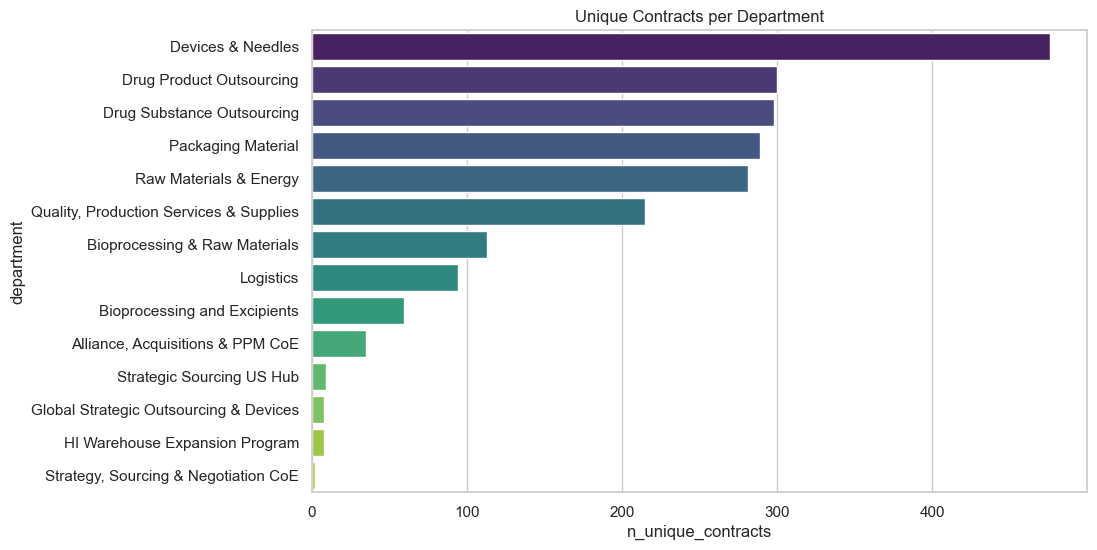

In [3]:
dept_dist = df.groupby("department").agg(
    n_rows=('contract_id', 'count'),
    n_unique_contracts=('contract_id', 'nunique')
).reset_index()

total_unique = dept_dist['n_unique_contracts'].sum()
dept_dist['pct_contracts'] = (dept_dist['n_unique_contracts'] / total_unique * 100).round(2)
dept_dist = dept_dist.sort_values("n_unique_contracts", ascending=False)

display(dept_dist)
save_table(dept_dist, "department_contract_distribution")

plt.figure(figsize=(10, 6))
sns.barplot(data=dept_dist, x='n_unique_contracts', y='department', palette='viridis')
plt.title("Unique Contracts per Department")
save_figure("department_contract_bar")

**Interpretation**: The department distribution reveals structural concentration. Logistics, as the target department, must be evaluated against the diversity of its peers.

## 3. Gold-Label Distribution by Department

Meta-learning requires diverse tasks with known outcomes. This section inventories the expert-validated labels currently available.

,department,gold_total,gold_yes,gold_no,gold_yes_rate
1,Devices & Needles,62,33,29,0.5323
3,Packaging Material,12,0,12,0.0000
2,Logistics,9,9,0,1.0000
0,Bioprocessing and Excipients,1,1,0,1.0000


Saved table to: ../reports/diagnostics/gold_label_distribution.csv
Saved figure to: ../reports/diagnostics/figures/gold_label_distribution_stacked_bar.png


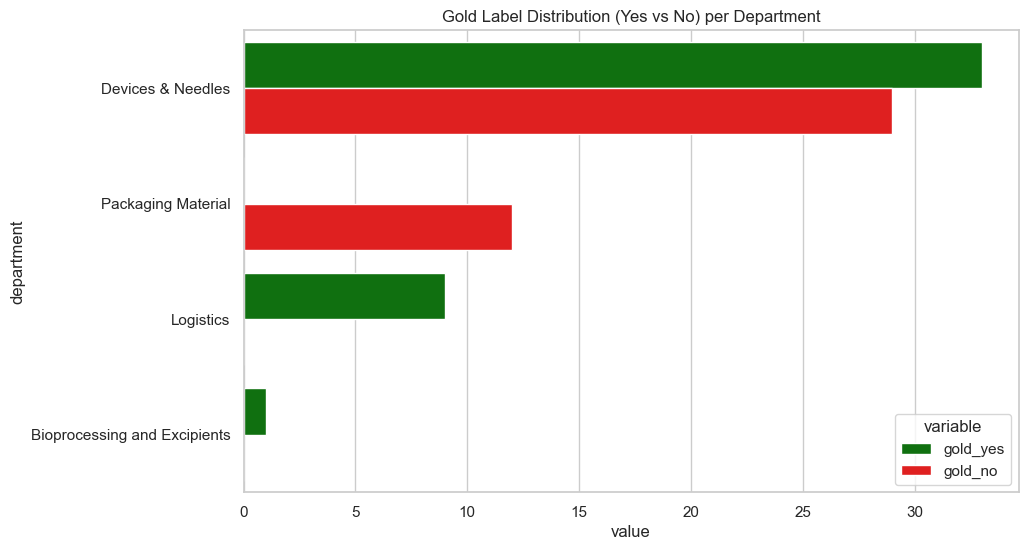

In [4]:
gold_dist = df[df['gold_y'].notnull()].groupby("department").agg(
    gold_total=('gold_y', 'count'),
    gold_yes=('gold_y', lambda x: (x == 1).sum()),
    gold_no=('gold_y', lambda x: (x == 0).sum())
).reset_index()

gold_dist['gold_yes_rate'] = (gold_dist['gold_yes'] / gold_dist['gold_total']).round(4)
gold_dist = gold_dist.sort_values("gold_total", ascending=False)

display(gold_dist)
save_table(gold_dist, "gold_label_distribution")

gold_plot_df = gold_dist.melt(id_vars='department', value_vars=['gold_yes', 'gold_no'])
plt.figure(figsize=(10, 6))
sns.barplot(data=gold_plot_df, x='value', y='department', hue='variable', palette={'gold_yes': 'green', 'gold_no': 'red'})
plt.title("Gold Label Distribution (Yes vs No) per Department")
save_figure("gold_label_distribution_stacked_bar")

**Interpretation**: Only a subset of departments possess sufficient labels of both classes. This sparsity defines the "few-shot" nature of the adaptation problem.

## 4. Gold-Label Coverage

The low coverage of gold labels across the full contract set is the primary motivator for using weak supervision (Stage 1) to learn from the unlabeled majority.

,department,n_unique_contracts,gold_total,gold_coverage_pct
0,Devices & Needles,476,62.0,13.03
1,Drug Product Outsourcing,300,0.0,0.00
2,Drug Substance Outsourcing,298,0.0,0.00
3,Packaging Material,289,12.0,4.15
4,Raw Materials & Energy,281,0.0,0.00
5,"Quality, Production Services & Supplies",215,0.0,0.00
6,Bioprocessing & Raw Materials,113,0.0,0.00
7,Logistics,94,9.0,9.57
8,Bioprocessing and Excipients,59,1.0,1.69
9,"Alliance, Acquisitions & PPM CoE",35,0.0,0.00


Saved table to: ../reports/diagnostics/gold_label_coverage.csv
Saved figure to: ../reports/diagnostics/figures/gold_label_coverage_bar.png


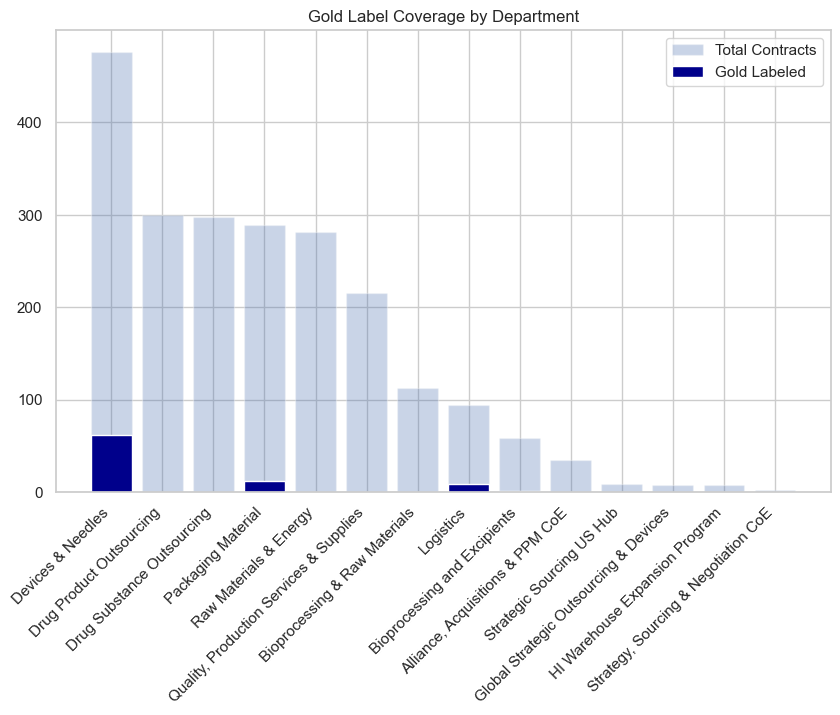

In [5]:
coverage = pd.merge(
    dept_dist[['department', 'n_unique_contracts']],
    gold_dist[['department', 'gold_total']],
    on='department', how='left'
).fillna(0)

coverage['gold_coverage_pct'] = (coverage['gold_total'] / coverage['n_unique_contracts'] * 100).round(2)
display(coverage)
save_table(coverage, "gold_label_coverage")

plt.figure(figsize=(10, 6))
plt.bar(coverage['department'], coverage['n_unique_contracts'], label='Total Contracts', alpha=0.3)
plt.bar(coverage['department'], coverage['gold_total'], label='Gold Labeled', color='darkblue')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.title("Gold Label Coverage by Department")
save_figure("gold_label_coverage_bar")

**Interpretation**: The extreme discrepancy between total contracts and gold labels underscores the necessity of leveraging Stage 1 Snorkel labels to capture the contract feature structure.

## 5. Stage 2 Task Validity Inventory

Determination of which departments can serve as "tasks" for MAML, based on the requirement for both positive and negative examples in both support and query sets.

In [6]:
def determine_role(row):
    if row['department'] == 'Logistics':
        return 'target_candidate'
    if row['gold_yes'] == 0 or row['gold_no'] == 0:
        return 'invalid_one_class'
    if row['gold_yes'] > 0 and row['gold_no'] > 0:
        return 'source_task'
    return 'unlabeled'

validity = gold_dist.copy()
for k in [2, 5, 10]:
    # Formula: valid if yes >= k+1 and no >= k+1 (k for support, 1 for query)
    validity[f'valid_k{k}'] = (validity['gold_yes'] >= k + 1) & (validity['gold_no'] >= k + 1)

validity['suggested_role'] = validity.apply(determine_role, axis=1)
display(validity)
save_table(validity, "stage2_task_validity")

,department,gold_total,gold_yes,gold_no,gold_yes_rate,valid_k2,valid_k5,valid_k10,suggested_role
1,Devices & Needles,62,33,29,0.5323,True,True,True,source_task
3,Packaging Material,12,0,12,0.0000,False,False,False,invalid_one_class
2,Logistics,9,9,0,1.0000,False,False,False,target_candidate
0,Bioprocessing and Excipients,1,1,0,1.0000,False,False,False,invalid_one_class


Saved table to: ../reports/diagnostics/stage2_task_validity.csv


**Interpretation**: If the number of `source_task` rows representing true class variance is low, meta-initialization stability may be compromised.

## 6. Overall Class Balance

Analysis of the positive/negative skew within the gold label distribution.

,metric,value
0,total_gold,84.0000
1,total_yes,43.0000
2,total_no,41.0000
3,yes_rate,0.5119


Saved table to: ../reports/diagnostics/class_balance.csv
Saved figure to: ../reports/diagnostics/figures/overall_class_balance_pie.png


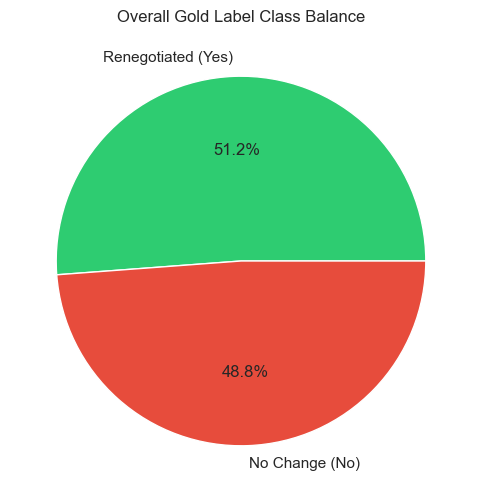

In [7]:
total_gold = len(df[df['gold_y'].notnull()])
total_yes = int(df['gold_y'].sum())
total_no = total_gold - total_yes

summary_balance = pd.DataFrame({
    "metric": ["total_gold", "total_yes", "total_no", "yes_rate"],
    "value": [total_gold, total_yes, total_no, round(total_yes / total_gold, 4)]
})
display(summary_balance)
save_table(summary_balance, "class_balance")

plt.figure(figsize=(6, 6))
plt.pie([total_yes, total_no], labels=['Renegotiated (Yes)', 'No Change (No)'], autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
plt.title("Overall Gold Label Class Balance")
save_figure("overall_class_balance_pie")

**Interpretation**: Imbalance affects the choice of metrics. While AUROC is resilient, Log-loss and Calibration (ECE) are sensitive to extreme priors.

## 7. Weak-Label / Snorkel Probability Distribution

If Snorkel probabilistic labels exist, we assess how they are distributed compared to the gold labels.

Saved figure to: ../reports/diagnostics/figures/snorkel_prob_hist.png


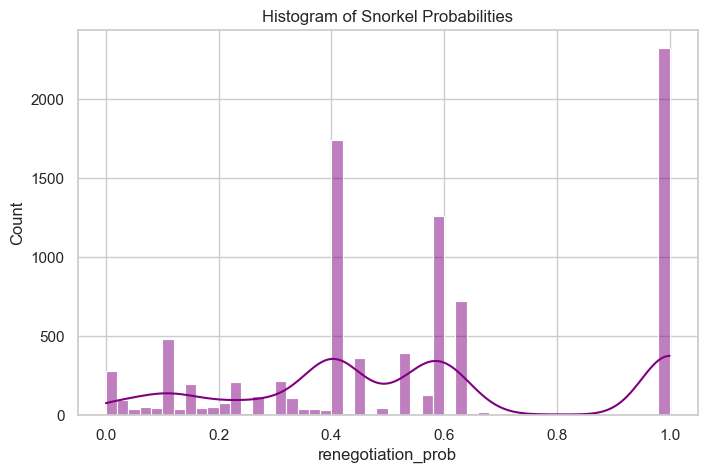

Saved figure to: ../reports/diagnostics/figures/snorkel_prob_boxplot.png


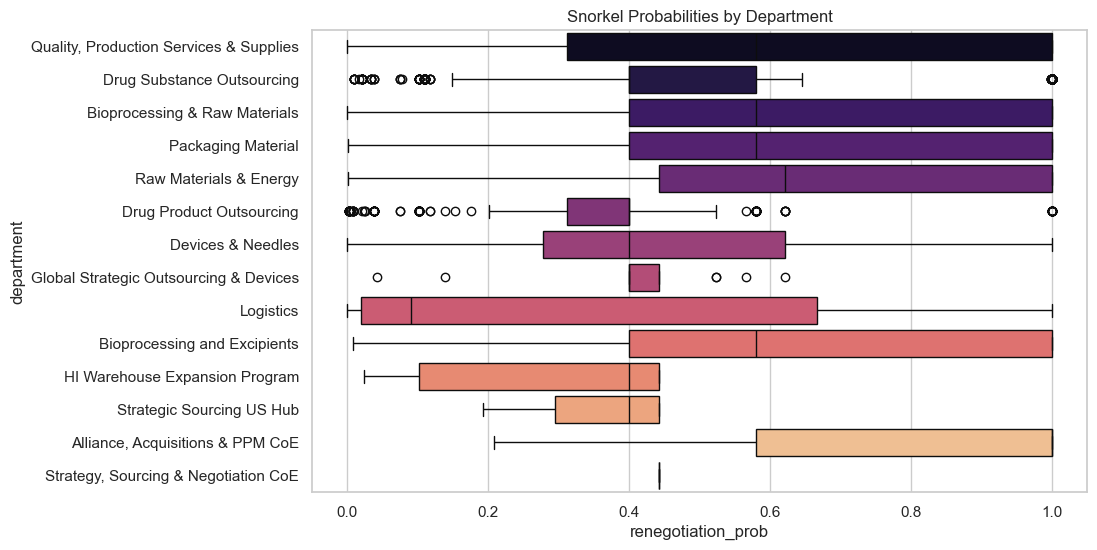

,department,mean,std,min,max
0,"Alliance, Acquisitions & PPM CoE",0.760780,0.262792,0.207530,1.000000
1,Bioprocessing & Raw Materials,0.586176,0.301794,0.000182,1.000000
2,Bioprocessing and Excipients,0.633646,0.305167,0.007811,1.000000
3,Devices & Needles,0.497098,0.317163,0.000182,1.000000
4,Drug Product Outsourcing,0.372403,0.188679,0.002826,1.000000
5,Drug Substance Outsourcing,0.508359,0.256601,0.009142,1.000000
6,Global Strategic Outsourcing & Devices,0.406135,0.118158,0.041809,0.621413
7,HI Warehouse Expansion Program,0.283995,0.187653,0.024094,0.442026
8,Logistics,0.335798,0.395121,0.000004,1.000000
9,Packaging Material,0.611310,0.286855,0.001438,1.000000


Saved table to: ../reports/diagnostics/weak_label_distribution_by_department.csv


In [8]:
if 'renegotiation_prob' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df['renegotiation_prob'], bins=50, kde=True, color='purple')
    plt.title("Histogram of Snorkel Probabilities")
    save_figure("snorkel_prob_hist")
    
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='renegotiation_prob', y='department', palette='magma')
    plt.title("Snorkel Probabilities by Department")
    save_figure("snorkel_prob_boxplot")
    
    snorkel_stats = df.groupby("department")['renegotiation_prob'].agg(['mean', 'std', 'min', 'max']).reset_index()
    display(snorkel_stats)
    save_table(snorkel_stats, "weak_label_distribution_by_department")
else:
    print("renegotiation_prob column not found. Skipping probabilistic analysis.")

## 8. Labeling-Function Vote Diagnostics

Checking for the presence of LF vote counts to assess labeling coverage.

In [9]:
vote_cols = ['lf_yes_votes', 'lf_no_votes', 'lf_abstain_votes']
available_votes = [c for c in vote_cols if c in df.columns]

if available_votes:
    vote_summary = df[available_votes].describe()
    display(vote_summary)
    save_table(vote_summary.reset_index(), "lf_vote_summary")
else:
    print("Data Gap: LF vote columns not found in this version of the processed dataset.")

Data Gap: LF vote columns not found in this version of the processed dataset.


## 9. Multi-View Feature Availability and Missingness

Aggregating columns into conceptual views to identify missingness patterns.

,view,n_features,avg_missing_pct,min_missing_pct,max_missing_pct
0,contract_core,5,12.620367,0.000000,32.507336
1,financial,58,40.057490,0.000000,88.631670
2,esg,12,74.167663,0.000000,89.001196
3,news,10,69.696772,0.000000,87.120965
4,market,13,34.122545,0.000000,98.489295
5,macro_logistics,7,0.773208,0.728182,1.043365
6,labels,3,33.029019,0.000000,99.087056


Saved table to: ../reports/diagnostics/view_missingness_summary.csv
Saved figure to: ../reports/diagnostics/figures/view_missingness_bar.png


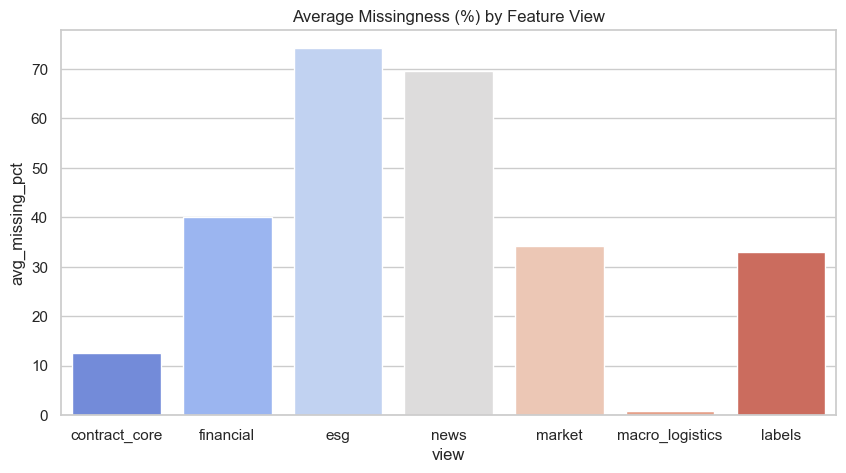

In [10]:
views = {
    "contract_core": ['contract_id', 'supplier_id', 'department', 'payment_terms', 'incoterms'],
    "financial": [c for c in df.columns if c.startswith('fin_')],
    "esg": [c for c in df.columns if c.startswith('esg_')],
    "news": [c for c in df.columns if c.startswith('news_')],
    "market": [c for c in df.columns if 'market' in c or c in ['avg_vol', 'price_volatility_score']],
    "macro_logistics": ['LPI_Score', 'PPI_Value', 'Customs', 'Infrastructure', 'International_Shipments', 'Logistics_Competence', 'Tracking_Tracing', 'Timeliness'],
    "labels": ['gold_y', 'target_renegotiate', 'renegotiation_prob']
}

view_stats = []
for view_name, cols in views.items():
    existing_cols = [c for c in cols if c in df.columns]
    if existing_cols:
        missing_pcts = df[existing_cols].isnull().mean() * 100
        view_stats.append({
            "view": view_name,
            "n_features": len(existing_cols),
            "avg_missing_pct": missing_pcts.mean(),
            "min_missing_pct": missing_pcts.min(),
            "max_missing_pct": missing_pcts.max()
        })

df_view_missing = pd.DataFrame(view_stats)
display(df_view_missing)
save_table(df_view_missing, "view_missingness_summary")

plt.figure(figsize=(10, 5))
sns.barplot(data=df_view_missing, x='view', y='avg_missing_pct', palette='coolwarm')
plt.title("Average Missingness (%) by Feature View")
save_figure("view_missingness_bar")

## 10. Feature Sanity Checks for Downstream Pipeline

Critical columns required for Stage 1, Stage 2 and evaluation.

In [11]:
required_cols = [
    'contract_id', 'supplier_id', 'department', 'observation_year', 'gold_y', 
    'target_renegotiate', 'renegotiation_prob', 'LPI_Score', 'PPI_Value', 
    'lpi_below_supplier_median', 'years_to_expiry_capped', 'days_until_expiry', 
    'open_ended_contract', 'is_old_and_near_expiry', 'esg_below_industry_min', 
    'supplier_is_publicly_listed', 'fin_flag_negative_ebit_margin', 
    'fin_flag_multiple_financial_stress_signals', 'payment_terms', 'incoterms', 
    'contract_age_years', 'expiry_pressure_bucket'
]

check_rows = []
for col in required_cols:
    present = col in df.columns
    missing_pct = df[col].isnull().mean() * 100 if present else np.nan
    dtype = df[col].dtype if present else "MISSING"
    check_rows.append({
        "column": col,
        "present": present,
        "missing_pct": missing_pct,
        "dtype": dtype
    })

df_sanity = pd.DataFrame(check_rows)
display(df_sanity)
save_table(df_sanity, "downstream_required_column_check")

missing_critical = df_sanity[~df_sanity['present']]['column'].tolist()
if missing_critical:
    print(f"WARNING: Critical columns missing: {missing_critical}")

,column,present,missing_pct,dtype
0,contract_id,True,0.000000,int64
1,supplier_id,True,0.000000,int64
2,department,True,0.999891,str
3,observation_year,True,0.000000,int64
4,gold_y,True,99.087056,float64
5,target_renegotiate,True,0.000000,int64
6,renegotiation_prob,True,0.000000,float64
7,LPI_Score,True,0.728182,float64
8,PPI_Value,True,1.043365,float64
9,lpi_below_supplier_median,True,0.000000,int64


Saved table to: ../reports/diagnostics/downstream_required_column_check.csv


## 11. Output Artifact Generation

Artifacts have been saved to `reports/diagnostics/` for inspection and documentation.

## 12. Final Executive Summary

Establish the meta-readiness score of the dataset.

In [12]:
print("--- EXECUTIVE SUMMARY ---")
print(f"Total Contracts: {df['contract_id'].nunique()}")
print(f"Total Departments: {df['department'].nunique()}")
print(f"Total Gold Labels: {gold_dist['gold_total'].sum()}")
print(f"Gold Labels: {total_yes} Yes / {total_no} No")

print(f"MAML Readiness (k=2): {validity['valid_k2'].sum()} valid source tasks")
print(f"MAML Readiness (k=5): {validity['valid_k5'].sum()} valid source tasks")

log_stats = gold_dist[gold_dist['department'] == 'Logistics']
if not log_stats.empty:
    print(f"Logistics Labels: {log_stats.iloc[0]['gold_total']} total, {log_stats.iloc[0]['gold_yes_rate']*100:.1f}% Positive rate")
else:
    print("WARNING: Logistics department has NO gold labels.")

highest_missing_view = df_view_missing.loc[df_view_missing['avg_missing_pct'].idxmax(), 'view']
print(f"Highest Missingness: {highest_missing_view} section")

print("\n--- PIPELINE SUPPORT STATUS ---")
print(f"a) Weak Supervision Support:   {'YES' if 'renegotiation_prob' in df.columns else 'PENDING'}")
print(f"b) Supervised MLP Support:      {'YES' if total_gold > 50 else 'NO'}")
print(f"c) Few-Shot Adaptation Support: {'YES' if not log_stats.empty else 'NO'}")
print(f"d) Full MAML Meta-Training:     {'YES' if validity['valid_k2'].sum() >= 5 else 'WEAK (Too few source tasks)'}")

--- EXECUTIVE SUMMARY ---
Total Contracts: 2209
Total Departments: 14
Total Gold Labels: 84
Gold Labels: 43 Yes / 41 No
MAML Readiness (k=2): 1 valid source tasks
MAML Readiness (k=5): 1 valid source tasks
Logistics Labels: 9 total, 100.0% Positive rate
Highest Missingness: esg section

--- PIPELINE SUPPORT STATUS ---
a) Weak Supervision Support:   YES
b) Supervised MLP Support:      YES
c) Few-Shot Adaptation Support: YES
d) Full MAML Meta-Training:     WEAK (Too few source tasks)
